In [5]:
#import neccessary libraries
import numpy as np
import evaluation as ev
import csv
import pandas as pd
import scipy.stats

#read position info info file as 
#set root file name
root_file = 'Gamma-E25-n1000-part9'

#read cluster distribution csv as a dataframe and get noise level that minimizes cluster number
df = pd.read_csv('cluster-noise-distribution_'+root_file+'.csv')
noise = df['noise'][df['n_clusters_mean'].idxmin()]

n_events=1000
cluster_n = 1
df_5v_res_n = pd.read_csv('particle-info_'+root_file+'_noise-'+str(noise)+'_event'+str(n_events)+'_signal'+str(cluster_n)+'.csv')
df_5v_res_n

In [127]:
#read ALL files into single dataframe
import glob

#read cluster distribution csv as a dataframe and get noise level that minimizes cluster number
root_file = 'Gamma-E200-n1000-part3'
df = pd.read_csv('cluster-noise-distribution_'+root_file+'.csv')
noise = df['noise'][df['n_clusters_mean'].idxmin()]

n_events=1000
cluster_n = 1

energy=200
all_files = glob.glob('particle-info_Gamma-E'+str(energy)+'-n1000-part*_noise-'+str(noise)+'_event'+str(n_events)+'_signal'+str(cluster_n)+'.csv')

df_5v_res_n = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df_5v_res_n

,event_n,x,y,z,e,t,clusterindex,cluster_count,sum(E_hit),RecHitHGC_x,RecHitHGC_y,RecHitHGC_z,GenVtx_x,GenVtx_y,GenVtx_z,GenHit_x,GenHit_y,Diff_x,Diff_y
0,0,87.58,-41.70,323.08,0.041,-1.000000,175,1,196.925,87.58,-41.70,323.08,89.31,-38.84,320.94,89.905511,-39.098982,2.325511,2.601018
1,0,89.67,-39.30,323.08,0.185,5.172852,175,1,196.925,89.67,-39.30,323.08,89.31,-38.84,320.94,89.905511,-39.098982,0.235511,0.201018
2,0,95.96,-61.01,323.08,0.012,-1.000000,175,1,196.925,95.96,-61.01,323.08,89.31,-38.84,320.94,89.905511,-39.098982,-6.054489,21.911018
3,0,85.50,-46.51,325.04,0.098,6.075684,175,1,196.925,85.50,-46.51,325.04,89.31,-38.84,320.94,90.450933,-39.336180,4.950933,7.173820
4,0,86.54,-47.11,325.04,0.029,-1.000000,175,1,196.925,86.54,-47.11,325.04,89.31,-38.84,320.94,90.450933,-39.336180,3.910933,7.773820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10461344,999,-78.87,65.27,367.70,0.044,-1.000000,51,1,197.961,-78.87,65.27,367.70,-63.81,58.84,320.50,-73.207292,67.505360,5.662708,2.235360
10461345,999,-77.83,64.67,367.70,0.091,-1.000000,51,1,197.961,-77.83,64.67,367.70,-63.81,58.84,320.50,-73.207292,67.505360,4.622708,2.835360
10461346,999,-73.61,75.56,367.70,0.257,5.124023,51,1,197.961,-73.61,75.56,367.70,-63.81,58.84,320.50,-73.207292,67.505360,0.402708,-8.054640
10461347,999,-70.49,61.64,373.15,0.120,-1.000000,51,1,197.961,-70.49,61.64,373.15,-63.81,58.84,320.50,-74.292360,68.505916,-3.802360,6.865916


df_5v_res_n = pd.concat([df_5v_res_1, df_5v_res_2, df_5v_res_3, df_5v_res_4, df_5v_res_5, df_5v_res_6, df_5v_res_7, df_5v_res_8, df_5v_res_9, df_5v_res_10], ignore_index=True)

In [128]:
df_t = df_5v_res_n[['event_n','e','t']]
df_t['t_updated'] = df_t['t'] - 5
df_t_filter = df_t
df_t_filter = df_t[df_t['t_updated']> -6]
df_t_filter = df_t[(df_t['t_updated']!=-6) & (df_t['t_updated'] < 1)]
df_t_filter = df_t_filter.reset_index(drop=True)
df_t_filter

,event_n,e,t,t_updated
0,0,0.185,5.172852,0.172852
1,0,0.078,5.075195,0.075195
2,0,0.456,5.148438,0.148438
3,0,0.121,5.197266,0.197266
4,0,0.051,5.416748,0.416748
...,...,...,...,...
4090356,999,0.053,5.172852,0.172852
4090357,999,0.129,5.099609,0.099609
4090358,999,0.187,5.026367,0.026367
4090359,999,0.036,5.758301,0.758301


In [129]:
#manually drop top 5% and compare
df_t_filter_5_manual = df_t_filter.sort_values(by='t_updated')
num_rows_to_drop = int(len(df_t_filter_5_manual) * 0.05)
print(num_rows_to_drop)
df_t_filter_5_manual.drop(df_t_filter_5_manual.tail(num_rows_to_drop).index,
        inplace = True)
df_t_filter_5_manual

204518


,event_n,e,t,t_updated
3652611,935,0.379,0.122002,-4.877998
1312755,243,0.165,0.170799,-4.829201
1469866,627,0.118,0.292801,-4.707199
2093289,145,0.124,0.317200,-4.682800
2093275,145,0.366,0.390396,-4.609604
...,...,...,...,...
419984,17,0.166,5.343506,0.343506
2228640,475,0.086,5.343506,0.343506
560483,359,0.068,5.343506,0.343506
1746212,303,0.099,5.343506,0.343506


#filter top %30 values
# Calculate the threshold value for the top 30%
threshold_5 = df_t_filter['t_updated'].quantile(0.95)
threshold_10 = df_t_filter['t_updated'].quantile(0.90)
threshold_15 = df_t_filter['t_updated'].quantile(0.85)
threshold_20 = df_t_filter['t_updated'].quantile(0.80)
threshold_25 = df_t_filter['t_updated'].quantile(0.75)
threshold_30 = df_t_filter['t_updated'].quantile(0.70)
## Filter the DataFrame
df_t_filter_5 = df_t_filter[df_t_filter['t_updated'] <= threshold_5]
df_t_filter_5 = df_t_filter_5.reset_index(drop=True)
df_t_filter_10 = df_t_filter[df_t_filter['t_updated'] <= threshold_10]
df_t_filter_10 = df_t_filter_10.reset_index(drop=True)
df_t_filter_15 = df_t_filter[df_t_filter['t_updated'] <= threshold_15]
df_t_filter_15 = df_t_filter_15.reset_index(drop=True)
df_t_filter_20 = df_t_filter[df_t_filter['t_updated'] <= threshold_20]
df_t_filter_20 = df_t_filter_20.reset_index(drop=True)
df_t_filter_25 = df_t_filter[df_t_filter['t_updated'] <= threshold_25]
df_t_filter_25 = df_t_filter_25.reset_index(drop=True)
df_t_filter_30 = df_t_filter[df_t_filter['t_updated'] <= threshold_30]
df_t_filter_30 = df_t_filter_30.reset_index(drop=True)
df_t_filter_5

#set x-axis limits
xmin = -0.2#round(df_t['t_updated'].min() - 1)
xmax = 0.35#round(df_t['t_updated'].max() + 1)

#set y-axis limits
ymin = -0.1
ymax = round(df_t['e'].max() + 0.1)

ax = df_t_filter.plot(x='t_updated', 
               y='e',
               title = 'Energy-Time Correlation',
               ylabel = 'Energy', 
               xlabel =  'Time',
               style='x',
               color='blue',
               legend = True,
               label = r'100%',
               alpha=0.5)

df_t_filter_5.plot(x='t_updated', 
               y='e',
               title = 'Energy-Time Correlation',
               ylabel = 'Energy', 
               xlabel =  'Time',
               style='x',
               color='green',
               legend = True,
               label = r'95%',
               alpha=0.4,
               ax=ax)

df_t_filter_10.plot(x='t_updated', 
               y='e',
               title = 'Energy-Time Correlation',
               ylabel = 'Energy', 
               xlabel =  'Time',
               style='x',
               color='r',
               legend = True,
               label = r'90%',
               alpha=0.4,
               ax=ax)

df_t_filter_15.plot(x='t_updated', 
               y='e',
               title = 'Energy-Time Correlation',
               ylabel = 'Energy', 
               xlabel =  'Time',
               style='x',
               color='c',
               legend = True,
               label = r'85%',
               alpha=0.4,
               ax=ax)

df_t_filter_20.plot(x='t_updated', 
               y='e',
               title = 'Energy-Time Correlation',
               ylabel = 'Energy', 
               xlabel =  'Time',
               style='x',
               color='m',
               legend = True,
               label = r'80%',
               alpha=0.4,
               ax=ax)

df_t_filter_25.plot(x='t_updated', 
               y='e',
               title = 'Energy-Time Correlation',
               ylabel = 'Energy', 
               xlabel =  'Time',
               style='x',
               color='y',
               legend = True,
               label = r'75%',
               alpha=0.4,
               ax=ax)

df_t_filter_30.plot(x='t_updated', 
               y='e',
               title = 'Energy-Time Correlation',
               ylabel = 'Energy', 
               xlabel =  'Time',
               style='x',
               color='brown',
               legend = True,
               label = r'70%',
               alpha=0.4,
               ax=ax)

#ax.axhline(1.0, color='k', linestyle='--', label='_nolabel_')

ax.set_xlim([xmin, xmax]) #uncomment for centered response
ax.set_ylim([ymin, ymax]) 

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')

#print percentage of values left out
percentage_above_threshold = (df_t_filter['t_updated'] > xmax).mean() * 100
print(f'{percentage_above_threshold=}')

count_above_threshold = (df_t_filter['t_updated'] > xmax).sum()
total_count = df_t_filter['t_updated'].count()
percentage_above_threshold_2 = (count_above_threshold / total_count) * 100
print(f'{percentage_above_threshold_2=}')
#ax.get_figure().savefig('cluster_response_rate-'+root_file+'_noise-'+str(noise)+'_signal' + str(cluster_n) +'.png', bbox_inches = 'tight')

In [130]:
#df_t_hist = df_t_filter[['e','t']]

#calculating the means
df_t_hist = df_t_filter[['event_n', 'e', 't_updated']]
df_t_hist = df_t_hist.groupby('event_n')
df_t_hist = df_t_hist.mean()
df_t_hist=df_t_hist.astype(float)
df_t_hist

,e,t_updated
event_n,,
0,0.377699,0.088320
1,0.445785,0.011982
2,0.433461,0.069516
3,0.458151,0.049730
4,0.428605,0.099279
...,...,...
995,0.456762,0.079727
996,0.411011,0.069572
997,0.454777,0.075189


In [131]:
threshold_9 = df_t_filter['t_updated'].quantile(0.91)
## Filter the DataFrame
df_t_filter = df_t_filter[df_t_filter['t_updated'] <= threshold_9]
df_t_filter_5 = df_t_filter.reset_index(drop=True)

In [132]:
#set up histogram bining for one event
bin_n = 25
#bin_width = (np.ceil(df_t_filter['t_updated'].max()) - np.floor(df_t_filter['t_updated'].min()))/bin_n
#custom_bins = np.arange(np.floor(df_t_filter['t_updated'].min()), np.ceil(df_t_filter['t_updated'].max()), bin_width)
bin_width = (1 - (-0.01))/bin_n
custom_bins = np.arange(-0.01, 1, bin_width)

custom_bins

array([-0.01  ,  0.0304,  0.0708,  0.1112,  0.1516,  0.192 ,  0.2324,
        0.2728,  0.3132,  0.3536,  0.394 ,  0.4344,  0.4748,  0.5152,
        0.5556,  0.596 ,  0.6364,  0.6768,  0.7172,  0.7576,  0.798 ,
        0.8384,  0.8788,  0.9192,  0.9596])

In [133]:
#custom binning for better fit
bin_min = -0.05
bin_max = 0.05
#bin_n = 80
#bin_width = (bin_max - bin_min)/bin_n
#custom_bins = np.arange(bin_min, bin_max, bin_width)

#df_t_filter = df_t_filter[(df_t_filter['t_updated']>=bin_min) & (df_t_filter['t_updated']<=bin_max)]

In [134]:
#set up bins weights so that summing the bars up gives 1
bin_weights = np.ones_like(df_t_filter['t_updated']) / len(df_t_filter['t_updated'])

In [135]:
#fit data to gaussian distribution
mu, std = scipy.stats.norm.fit(df_t_filter['t_updated'])
g = scipy.stats.norm.pdf(custom_bins, mu, std)

In [136]:
#get fit weight correction for weighted/density histogram
sums_w, bins_w = np.histogram(df_t_filter['t_updated'], custom_bins, weights = bin_weights)
sums_d, bins_d = np.histogram(df_t_filter['t_updated'], custom_bins, density = True)
g_weight = np.amax(sums_w)/np.amax(sums_d)

#set x-axis limits so that histogram is centered
xmin = -1
xmax = 1

#plot histogram 
ax = df_t_filter.plot('t_updated',#,+diff, 
        kind='hist', 
        bins=custom_bins,
        density=False,
        weights = bin_weights,
        title = 'Histogram of t: μ ='+str(np.round(mu,2))+', σ ='+str(np.round(std,2)),
        ylabel = 'Events', 
        xlabel='Time',
        rot = 0,
        color='blue',
        legend = None,
        figsize=(6, 4),
        alpha=0.3)

#plot gaussian fit
#ax.plot(custom_bins, g*g_weight, color='red', linestyle='dashed')

#set plot parameters
ax.set_axisbelow(True)
ax.set_xlim([xmin, xmax]) #uncomment for centered histogram
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.xaxis.grid(color='gray', linestyle='dashed')
#ax.get_figure().savefig('energy-distribution-'+root_file+'_noise-'+str(noise)+'_signal'+str(cluster_n)+'.png', bbox_inches = 'tight')

In [137]:
#set up histogram bining for all events
bin_n = 120
bin_width = (np.ceil(df_t_hist['t_updated'].max()) - np.floor(df_t_hist['t_updated'].min()))/bin_n
custom_bins = np.arange(np.floor(df_t_hist['t_updated'].min()), np.ceil(df_t_hist['t_updated'].max()), bin_width)

custom_bins

array([-1.00000000e+00, -9.83333333e-01, -9.66666667e-01, -9.50000000e-01,
       -9.33333333e-01, -9.16666667e-01, -9.00000000e-01, -8.83333333e-01,
       -8.66666667e-01, -8.50000000e-01, -8.33333333e-01, -8.16666667e-01,
       -8.00000000e-01, -7.83333333e-01, -7.66666667e-01, -7.50000000e-01,
       -7.33333333e-01, -7.16666667e-01, -7.00000000e-01, -6.83333333e-01,
       -6.66666667e-01, -6.50000000e-01, -6.33333333e-01, -6.16666667e-01,
       -6.00000000e-01, -5.83333333e-01, -5.66666667e-01, -5.50000000e-01,
       -5.33333333e-01, -5.16666667e-01, -5.00000000e-01, -4.83333333e-01,
       -4.66666667e-01, -4.50000000e-01, -4.33333333e-01, -4.16666667e-01,
       -4.00000000e-01, -3.83333333e-01, -3.66666667e-01, -3.50000000e-01,
       -3.33333333e-01, -3.16666667e-01, -3.00000000e-01, -2.83333333e-01,
       -2.66666667e-01, -2.50000000e-01, -2.33333333e-01, -2.16666667e-01,
       -2.00000000e-01, -1.83333333e-01, -1.66666667e-01, -1.50000000e-01,
       -1.33333333e-01, -

In [138]:
#custom binning for better fit
bin_min = -0.0005
bin_max = 0.0005
#bin_n = 80
#bin_width = (bin_max - bin_min)/bin_n
#custom_bins = np.arange(bin_min, bin_max, bin_width)

#df_t_hist = df_t_hist[(df_t_hist['t_updated']>=bin_min) & (df_t_hist['t_updated']<=bin_max)]

In [139]:
#set up bins weights so that summing the bars up gives 1
bin_weights = np.ones_like(df_t_hist['t_updated']) / len(df_t_hist['t_updated'])

In [140]:
#fit data to gaussian distribution
mu, std = scipy.stats.norm.fit(df_t_hist['t_updated'])
g = scipy.stats.norm.pdf(custom_bins, mu, std)

In [141]:
#get fit weight correction for weighted/density histogram
sums_w, bins_w = np.histogram(df_t_hist['t_updated'], custom_bins, weights = bin_weights)
sums_d, bins_d = np.histogram(df_t_hist['t_updated'], custom_bins, density = True)
g_weight = np.amax(sums_w)/np.amax(sums_d)

In [142]:
df_t_hist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   e          1000 non-null   float64
 1   t_updated  1000 non-null   float64
dtypes: float64(2)
memory usage: 23.4 KB


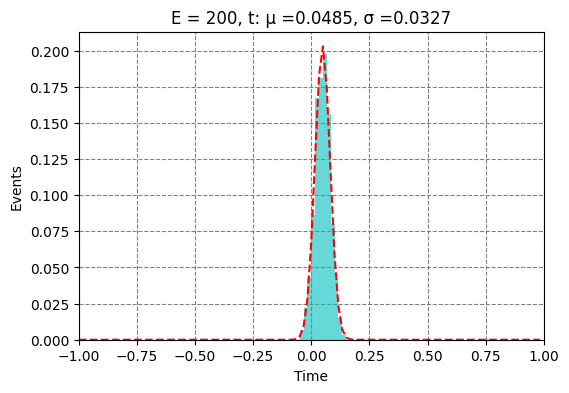

In [143]:
#set x-axis limits so that histogram is centered
xmin = -1
xmax = 1

#fix no numeric data to plot error
#df_t_hist.t_updated=pd.to_numeric(df_t_hist.t_updated)

#plot histogram 
ax = df_t_hist.plot('e',#,+diff, 
        kind='hist', 
        bins=custom_bins,
        density=False,
        weights = bin_weights,
        title = 'E = '+str(energy)+', t: μ ='+str(np.round(mu,4))+', σ ='+str(np.round(std,4)),
        ylabel = 'Events', 
        xlabel='Time',
        rot = 0,
        color='c',
        legend = None,
        figsize=(6, 4),
        alpha=0.6)

#plot gaussian fit
ax.plot(custom_bins, g*g_weight, color='red', linestyle='dashed')

#set plot parameters
ax.set_axisbelow(True)
ax.set_xlim([xmin, xmax]) #uncomment for centered histogram
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.xaxis.grid(color='gray', linestyle='dashed')
ax.get_figure().savefig('time_distribution_E'+str(energy)+'_new.png', bbox_inches = 'tight')